In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms
from PIL import Image
import timm
from sklearn.metrics import roc_auc_score
import numpy as np

image_folder = '/content/drive/MyDrive/EMBED-emory/path_severity'

# --- Custom Dataset ---
class SeverityBiradsDataset(torch.utils.data.Dataset):
    # Map BIRADS letter to number
    birads_map = {'A': 0, 'N': 1, 'B': 2, 'P': 3, 'S': 4, 'M': 5, 'K': 6}

    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(os.listdir(root_dir)))}
        for class_name in sorted(os.listdir(root_dir)):
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_folder):
                continue
            for img_folder in os.listdir(class_folder):
                img_folder_path = os.path.join(class_folder, img_folder)
                if not os.path.isdir(img_folder_path):
                    continue
                for fname in os.listdir(img_folder_path):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(img_folder_path, fname)
                        birads_letter = fname[0]
                        birads_digit = self.birads_map.get(birads_letter, -1)  # -1 if not found
                        label = self.class_to_idx[class_name]
                        self.samples.append((img_path, float(birads_digit), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, birads_digit, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        birads_tensor = torch.tensor([birads_digit], dtype=torch.float32)
        return img, birads_tensor, label

# --- Preprocessing ---
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1979, 0.1979, 0.1979], std=[0.1969, 0.1969, 0.1969]),
])

full_dataset = SeverityBiradsDataset(image_folder, transform=preprocess)
num_classes = len(full_dataset.class_to_idx)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# --- ViT + Tabular Fusion Model ---
class ViTWithBirads(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        self.vit.head = nn.Identity()  # Remove default head
        self.tabular = nn.Linear(1, 32)  # For BIRADS digit
        self.classifier = nn.Linear(self.vit.num_features + 32, num_classes)

    def forward(self, x_img, x_birads):
        img_feat = self.vit(x_img)
        tab_feat = self.tabular(x_birads)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        out = self.classifier(combined)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViTWithBirads(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# --- Training Loop ---
epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, birads, labels in train_loader:
        images = images.to(device)
        birads = birads.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images, birads)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# --- Evaluation ---
model.eval()
# --- Save the trained model ---
save_path = "/content/drive/MyDrive/EMBED-emory/vit_birads_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
}, save_path)
print(f"✅ Model saved to {save_path}")

correct, total = 0, 0
all_labels = []
all_probs = []
with torch.no_grad():
    for images, birads, labels in test_loader:
        images = images.to(device)
        birads = birads.to(device)
        labels = labels.to(device)
        outputs = model(images, birads)
        probs = torch.softmax(outputs, dim=1)
        if num_classes == 2:
            class1_probs = probs[:, 1].cpu().numpy()
            all_probs.extend(class1_probs)
        else:
            all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
print(f"Test Accuracy: {100 * correct / total:.2f}%")

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

if num_classes == 2:
    auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC AUC: {auc:.4f}")
else:
    # Reshape all_probs to (n_samples, n_classes) for multiclass AUC
    all_probs = all_probs.reshape(-1, num_classes)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    print(f"Multiclass ROC AUC: {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch [1/30], Loss: 1.3531
Epoch [2/30], Loss: 1.1601
Epoch [3/30], Loss: 1.1163
Epoch [4/30], Loss: 1.1302
Epoch [5/30], Loss: 1.0106
Epoch [6/30], Loss: 0.8724
Epoch [7/30], Loss: 0.9013
Epoch [8/30], Loss: 0.6329
Epoch [9/30], Loss: 0.6335
Epoch [10/30], Loss: 0.4306
Epoch [11/30], Loss: 0.3175
Epoch [12/30], Loss: 0.2729
Epoch [13/30], Loss: 0.2433
Epoch [14/30], Loss: 0.2353
Epoch [15/30], Loss: 0.1382
Epoch [16/30], Loss: 0.0553
Epoch [17/30], Loss: 0.0563
Epoch [18/30], Loss: 0.0377
Epoch [19/30], Loss: 0.0542
Epoch [20/30], Loss: 0.1745
Epoch [21/30], Loss: 0.1025
Epoch [22/30], Loss: 0.1014
Epoch [23/30], Loss: 0.1897
Epoch [24/30], Loss: 0.0916
Epoch [25/30], Loss: 0.1184
Epoch [26/30], Loss: 0.1113
Epoch [27/30], Loss: 0.0341
Epoch [28/30], Loss: 0.0256
Epoch [29/30], Loss: 0.0142
Epoch [30/30], Loss: 0.0179
✅ Model saved to /content/drive/MyDrive/EMBED-emory/vit_birads_model.pth
Test Accuracy: 48.62%


ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'

adding train on top of already existing and saved model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from PIL import Image
import timm
import os

# --- Custom Dataset ---
class SeverityBiradsDataset(torch.utils.data.Dataset):
    birads_map = {'A': 0, 'N': 1, 'B': 2, 'P': 3, 'S': 4, 'M': 5, 'K': 6}

    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(os.listdir(root_dir)))}
        for class_name in sorted(os.listdir(root_dir)):
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_folder):
                continue
            for img_folder in os.listdir(class_folder):
                img_folder_path = os.path.join(class_folder, img_folder)
                if not os.path.isdir(img_folder_path):
                    continue
                for fname in os.listdir(img_folder_path):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(img_folder_path, fname)
                        birads_letter = fname[0]
                        birads_digit = self.birads_map.get(birads_letter, -1)
                        label = self.class_to_idx[class_name]
                        self.samples.append((img_path, float(birads_digit), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, birads_digit, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        birads_tensor = torch.tensor([birads_digit], dtype=torch.float32)
        return img, birads_tensor, label


# --- Paths ---
image_folder = '/content/drive/MyDrive/EMBED-emory/path_severity'
save_path = "/content/drive/MyDrive/EMBED-emory/vit_birads_model.pth"

# --- Preprocessing ---
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1979, 0.1979, 0.1979], std=[0.1969, 0.1969, 0.1969]),
])

# --- Dataset ---
full_dataset = SeverityBiradsDataset(image_folder, transform=preprocess)
num_classes = len(full_dataset.class_to_idx)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


# --- Model ---
class ViTWithBirads(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        self.vit.head = nn.Identity()
        self.tabular = nn.Linear(1, 32)
        self.classifier = nn.Linear(self.vit.num_features + 32, num_classes)

    def forward(self, x_img, x_birads):
        img_feat = self.vit(x_img)
        tab_feat = self.tabular(x_birads)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        return self.classifier(combined)


# --- Load Model + Optimizer States ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViTWithBirads(num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

start_epoch = 0
if os.path.exists(save_path):
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'epoch' in checkpoint:
        start_epoch = checkpoint['epoch'] + 1
    print(f"✅ Loaded checkpoint from epoch {start_epoch}")
else:
    print("⚠️ No previous checkpoint found, starting from scratch.")

criterion = nn.CrossEntropyLoss()


# --- Continue Training ---
more_epochs = 10
for epoch in range(start_epoch, start_epoch + more_epochs):
    model.train()
    running_loss = 0.0
    for images, birads, labels in train_loader:
        images, birads, labels = images.to(device), birads.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images, birads)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}], Loss: {running_loss/len(train_loader):.4f}")

    # --- Save Checkpoint Each Epoch ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'num_classes': num_classes,
    }, save_path)
    print(f"💾 Checkpoint saved at epoch {epoch+1} to {save_path}")

print(f"✅ Finished additional {more_epochs} epochs and saved final model.")


# **Creating a saliency map for 2 images of each 2 categories of pathology severity, heatmaps**

Saliency map plot saved to /content/drive/MyDrive/EMBED-emory/saliency_maps_wider.png


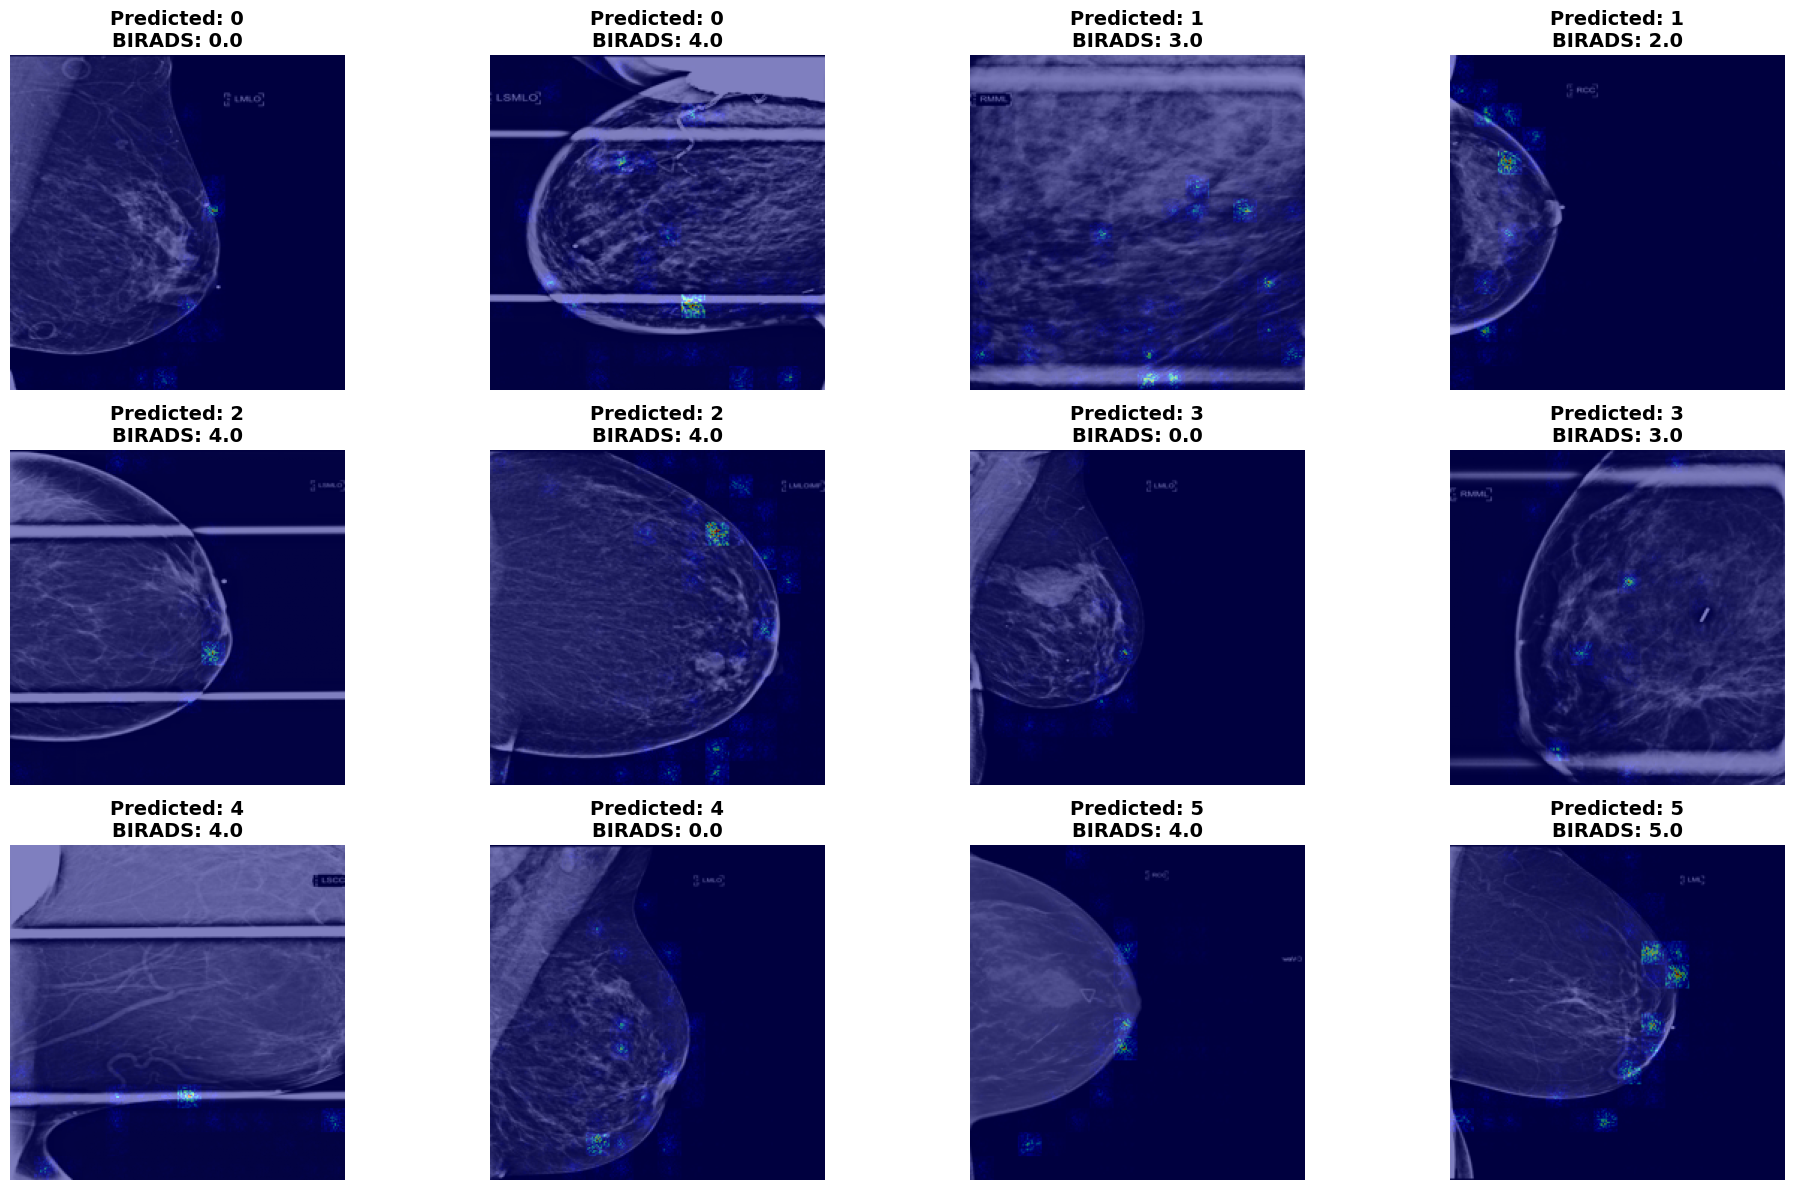

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import timm
import matplotlib.cm as cm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Model Definition ---
class ViTWithBirads(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        self.vit.head = nn.Identity()
        self.tabular = nn.Linear(1, 32)
        self.classifier = nn.Linear(self.vit.num_features + 32, num_classes)

    def forward(self, x_img, x_birads):
        img_feat = self.vit(x_img)
        tab_feat = self.tabular(x_birads)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        out = self.classifier(combined)
        return out

# --- Load saved model ---
checkpoint_path = "/content/drive/MyDrive/EMBED-emory/vit_birads_model.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
num_classes = checkpoint['num_classes']

model = ViTWithBirads(num_classes).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- Preprocessing ---
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1979, 0.1979, 0.1979],
                         std=[0.1969, 0.1969, 0.1969]),
])

# --- Placeholder for 6 image paths ---
image_folder = '/content/drive/MyDrive/EMBED-emory/path_severity'
image_paths = [
    "/content/drive/MyDrive/EMBED-emory/path_severity/0/1.2.826.0.1.3680043.8.498.10463462949968071640917373132244579064/A_1.2.826.0.1.3680043.8.498.10463462949968071640917373132244579064.png", #class 0 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/0/1.2.826.0.1.3680043.8.498.13150555384665408027620651365796483654/S_1.2.826.0.1.3680043.8.498.13150555384665408027620651365796483654.png", #class 0 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/1/1.2.826.0.1.3680043.8.498.11698864265696291743622238824566116301/P_1.2.826.0.1.3680043.8.498.11698864265696291743622238824566116301.png", #class 1 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/1/1.2.826.0.1.3680043.8.498.12571984441104804915475827312986914976/B_1.2.826.0.1.3680043.8.498.12571984441104804915475827312986914976.png", #class 1 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/2/1.2.826.0.1.3680043.8.498.10578803589782839800694914292201052453/S_1.2.826.0.1.3680043.8.498.10578803589782839800694914292201052453.png", #class 2 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/2/1.2.826.0.1.3680043.8.498.36718295897936788458867912281600860835/S_1.2.826.0.1.3680043.8.498.36718295897936788458867912281600860835.png", #class 2 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/3/1.2.826.0.1.3680043.8.498.10515179099809884558072228869429772910/A_1.2.826.0.1.3680043.8.498.10515179099809884558072228869429772910.png", #class 3 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/3/1.2.826.0.1.3680043.8.498.10133778865964935505923123081080834180/P_1.2.826.0.1.3680043.8.498.10133778865964935505923123081080834180.png", #class 3 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/4/1.2.826.0.1.3680043.8.498.11040836967402324950140478183708384098/S_1.2.826.0.1.3680043.8.498.11040836967402324950140478183708384098.png", #class 4 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/4/1.2.826.0.1.3680043.8.498.66997790020534025817264383777679081965/A_1.2.826.0.1.3680043.8.498.66997790020534025817264383777679081965.png", #class 4 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/5/1.2.826.0.1.3680043.8.498.10720847098060117664172920004797843228/S_1.2.826.0.1.3680043.8.498.10720847098060117664172920004797843228.png", #class 5 path severity
    "/content/drive/MyDrive/EMBED-emory/path_severity/5/1.2.826.0.1.3680043.8.498.11015466208142463712209257279997140926/M_1.2.826.0.1.3680043.8.498.11015466208142463712209257279997140926.png", #class 5 path severity
]

# --- BIRADS mapping ---
birads_map = {'A': 0, 'N': 1, 'B': 2, 'P': 3, 'S': 4, 'M': 5, 'K': 6}

def get_birads_from_filename(filename):
    letter = os.path.basename(filename)[0].upper()
    return float(birads_map.get(letter, 0))

# --- Map path_severity folders to numeric classes ---
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(os.listdir(image_folder)))}

# --- Compute saliency maps and plot in a 2x6 grid ---
plt.figure(figsize=(20, 12))  # 2 rows, 6 columns

for i, img_path in enumerate(image_paths):
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    img_tensor.requires_grad_()

    birads_value = get_birads_from_filename(img_path)
    birads_tensor = torch.tensor([[birads_value]], dtype=torch.float32).to(device)

    # Forward + backward pass
    output = model(img_tensor, birads_tensor)
    pred_class = output.argmax(dim=1).item()
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # Saliency map
    saliency = img_tensor.grad.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    # Overlay heatmap
    img_np = np.array(img_pil.resize((224,224))) / 255.0
    cmap = cm.jet(saliency)[:, :, :3]
    overlay = 0.5 * img_np + 0.5 * cmap

    # True class from path_severity
    true_class_name = os.path.basename(os.path.dirname(img_path))
    true_class_num = class_to_idx.get(true_class_name, -1)

    # Plot
    plt.subplot(3, 4, i+1)
    plt.imshow(overlay)
    plt.title(
      f"Predicted: {pred_class}\nBIRADS: {birads_value}",
      fontsize=14,        # increase for larger text (e.g., 16, 18)
      fontweight='bold')   # makes text bold
    plt.axis('off')
%matplotlib inline

plt.tight_layout()

save_plot_path = "/content/drive/MyDrive/EMBED-emory/saliency_maps_wider.png"
plt.savefig(save_plot_path, bbox_inches='tight', dpi=300)
print(f"Saliency map plot saved to {save_plot_path}")

plt.show()

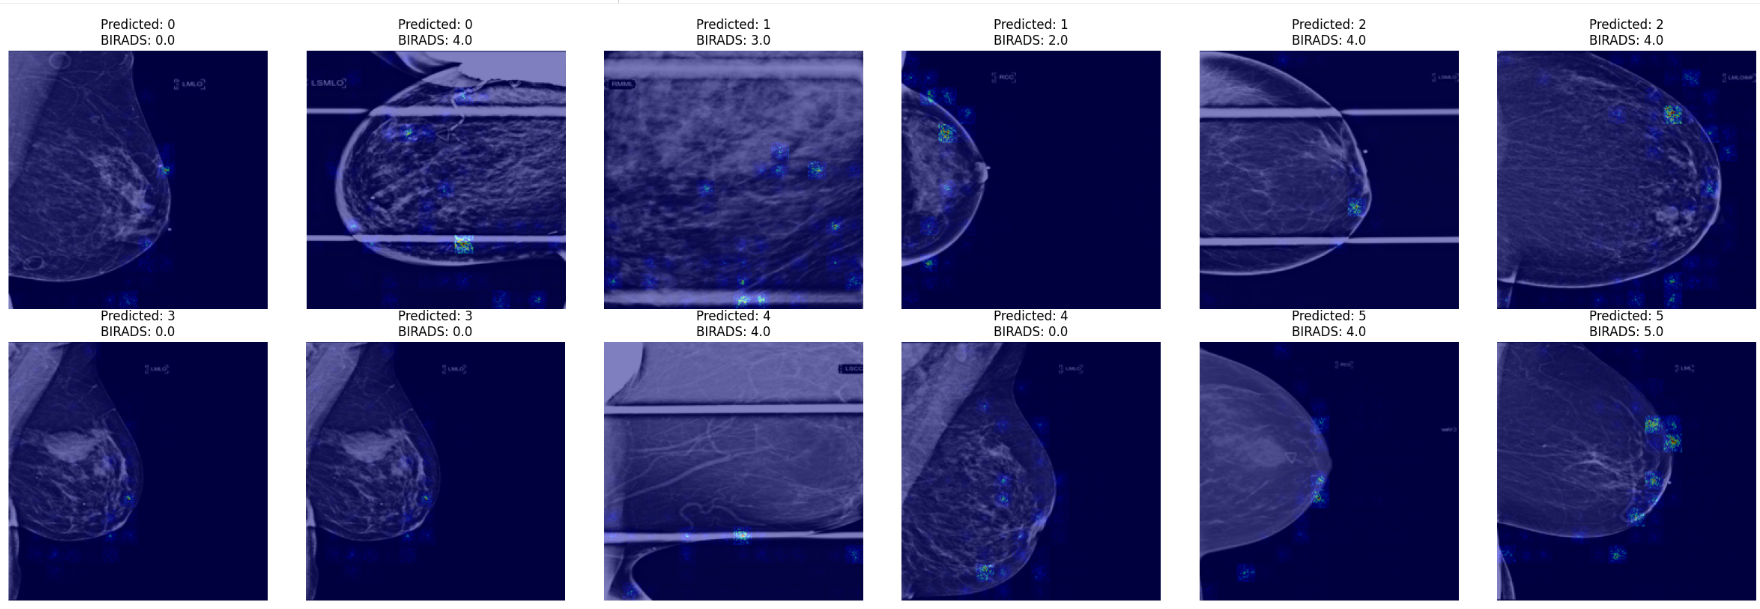


# **Code to evaluate the model - random XX% test set, confusion matrix, accuracy and roc-auc**


✅ Model loaded successfully from /content/drive/MyDrive/EMBED-emory/vit_birads_model.pth

✅ Test Accuracy: 87.17%
ROC AUC: 0.9782

🔢 Confusion Matrix:
[[82  5  0  0  2  1]
 [ 3 90  0  0  3  0]
 [ 1  0 88  1  5  5]
 [ 0  0  1 90  3  1]
 [11  3  3  4 65  3]
 [10  2  2  0  4 81]]


<Figure size 600x500 with 0 Axes>

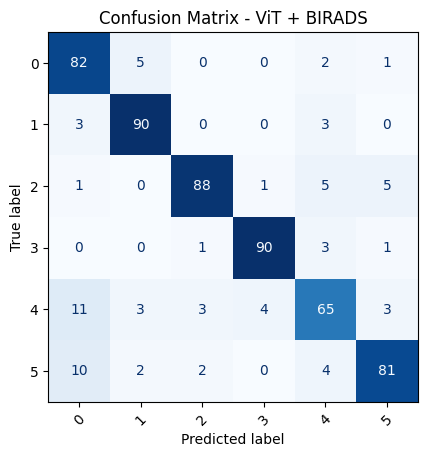

In [4]:
import os
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import timm
import numpy as np
from sklearn.metrics import roc_auc_score

# --- Paths ---
image_folder = '/content/drive/MyDrive/EMBED-emory/path_severity'
model_path = '/content/drive/MyDrive/EMBED-emory/vit_birads_model.pth'

# --- Dataset definition ---
class SeverityBiradsDataset(torch.utils.data.Dataset):
    birads_map = {'A': 0, 'N': 1, 'B': 2, 'P': 3, 'S': 4, 'M': 5, 'K': 6}

    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(os.listdir(root_dir)))}
        for class_name in sorted(os.listdir(root_dir)):
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_folder):
                continue
            for img_folder in os.listdir(class_folder):
                img_folder_path = os.path.join(class_folder, img_folder)
                if not os.path.isdir(img_folder_path):
                    continue
                for fname in os.listdir(img_folder_path):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(img_folder_path, fname)
                        birads_letter = fname[0]
                        birads_digit = self.birads_map.get(birads_letter, -1)
                        label = self.class_to_idx[class_name]
                        self.samples.append((img_path, float(birads_digit), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, birads_digit, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        birads_tensor = torch.tensor([birads_digit], dtype=torch.float32)
        return img, birads_tensor, label

# --- Model definition ---
class ViTWithBirads(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=False)
        self.vit.head = nn.Identity()
        self.tabular = nn.Linear(1, 32)
        self.classifier = nn.Linear(self.vit.num_features + 32, num_classes)

    def forward(self, x_img, x_birads):
        img_feat = self.vit(x_img)
        tab_feat = self.tabular(x_birads)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        out = self.classifier(combined)
        return out

# --- Transform ---
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1979]*3, std=[0.1969]*3),
])

# --- Load dataset ---
full_dataset = SeverityBiradsDataset(image_folder, transform=preprocess)
num_classes = len(full_dataset.class_to_idx)

# --- Split: 80% train, 20% test ---
test_size = int(0.5 * len(full_dataset))
train_size = len(full_dataset) - test_size
_, test_dataset = random_split(full_dataset, [train_size, test_size])

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# --- Load model ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViTWithBirads(num_classes).to(device)

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Model loaded successfully from {model_path}")

# --- Evaluate ---
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Evaluate ---
correct, total = 0, 0
all_labels, all_probs, all_preds = [], [], []

with torch.no_grad():
    for images, birads, labels in test_loader:
        images, birads, labels = images.to(device), birads.to(device), labels.to(device)
        outputs = model(images, birads)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = 100 * correct / total
print(f"\n✅ Test Accuracy: {test_acc:.2f}%")

# --- ROC AUC ---
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
try:
    if num_classes == 2:
        auc = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    print(f"ROC AUC: {auc:.4f}")
except Exception as e:
    print(f"⚠️ ROC AUC not computed: {e}")

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
print("\n🔢 Confusion Matrix:")
print(cm)

# Optional: visualize confusion matrix as heatmap
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(full_dataset.class_to_idx.keys()))
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - ViT + BIRADS")
plt.show()
